In [1]:
# load libraries
import pandas as pd
import numpy as np
# train test split
from sklearn.model_selection import train_test_split
# GridSearchCV - hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost
# metrics
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
# data visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import shap


c:\Users\shafe\Documents\DSI\ds4\ds4\ds4-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Setting random seed for reproducibility
np.random.seed(42)

Import Data

In [3]:
df = pd.read_csv('../02_src/uci_diabetes.csv')

Data Cleaning

In [4]:
# Binary encoding
binary_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

# dropping demographic data and class (y variable)
symptom_cols = df.columns.drop(["Age", "Gender", "class"])

df[symptom_cols] = df[symptom_cols].replace(binary_map)
df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)


C:\Users\shafe\AppData\Local\Temp\ipykernel_2388\111911585.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_2388\111911585.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace(gender_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_2388\111911585.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly 

In [5]:

df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,30,45,60,100],
                        labels=['<30','30–44','45–59','60+'])

# for these algorithms, we will not need the Age as an int
df = df.drop(columns=['Age'])

In [6]:
# Perform one-hot encoding on the 'AgeGroup' column
#  drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['AgeGroup'], prefix='AgeGroup',  drop_first=True)

print(df_encoded.columns)

Index(['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
       'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
       'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class', 'AgeGroup_30–44',
       'AgeGroup_45–59', 'AgeGroup_60+'],
      dtype='object')


In [7]:
# target (y) dataset
target = df['class']
target

0      1
1      1
2      1
3      1
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: class, Length: 520, dtype: int64

In [8]:
# predictors dataset
df_data = df_encoded.drop(columns=['class'])
df_data

,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,AgeGroup_30–44,AgeGroup_45–59,AgeGroup_60+
0,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,True,False,False
1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,False,True,False
2,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,True,False,False
3,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,True,False,False
4,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,1,1,1,1,0,1,0,0,1,0,1,1,0,0,0,True,False,False
516,1,1,1,1,1,1,0,0,1,1,1,1,0,0,0,False,True,False
517,1,1,1,1,1,1,0,1,0,0,0,1,1,0,1,False,True,False
518,1,0,0,0,1,0,0,1,1,0,1,0,0,1,0,True,False,False


X and Y

In [9]:
X = df_data
y = target

In [10]:
# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle= True, stratify = y,
) #

Subroutine that will be reused for evaluation

In [11]:
# subroutine for evaluation
def evaluation(model, X_test, y_test):
    # testing
    y_pred = model.predict(X_test)

    print(classification_report(y_pred, y_test))

    # Evaluation
    # Get the default accuracy score
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy Score: {accuracy}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=model.classes_)
    disp.plot()
    plt.show()

    # Calculate the log loss
    y_pred_proba = model.predict_proba(X_test)
    loss = log_loss(y_test, y_pred_proba)

    print(f"Log Loss: {loss}")

Testing with Logistic Regression

              precision    recall  f1-score   support

           0       0.97      0.89      0.93        44
           1       0.92      0.98      0.95        60

    accuracy                           0.94       104
   macro avg       0.95      0.93      0.94       104
weighted avg       0.94      0.94      0.94       104

Accuracy Score: 0.9423076923076923


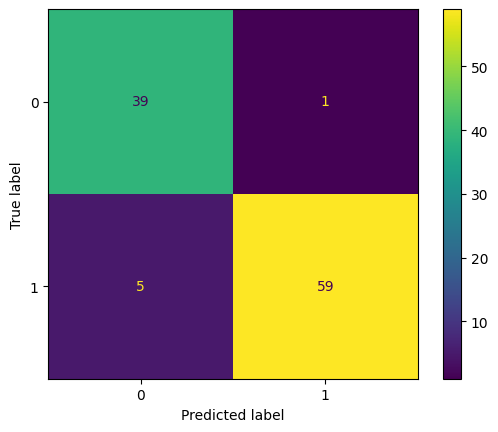

Log Loss: 0.15347693810880103


In [12]:
# Initialize
model = LogisticRegression()
# Train Model
model.fit(X_train, y_train) 

evaluation(model, X_test, y_test)

Decision Tree Classifier

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        42
           1       0.92      0.95      0.94        62

    accuracy                           0.92       104
   macro avg       0.92      0.92      0.92       104
weighted avg       0.92      0.92      0.92       104

Accuracy Score: 0.9230769230769231


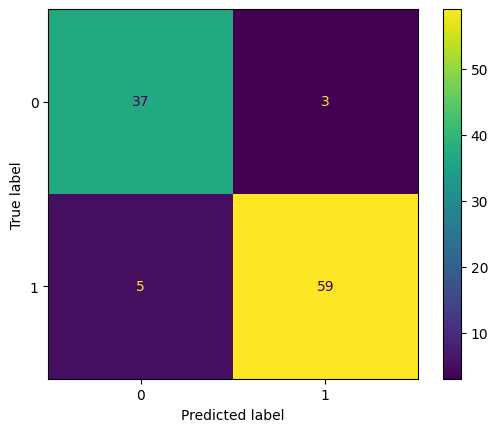

Log Loss: 2.438060929733802


In [13]:
# Initialize
model = DecisionTreeClassifier()
# Train model
model.fit(X_train, y_train)

evaluation(model, X_test, y_test)



Random Forest Classifier

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        41
           1       0.97      0.98      0.98        63

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104

Accuracy Score: 0.9711538461538461


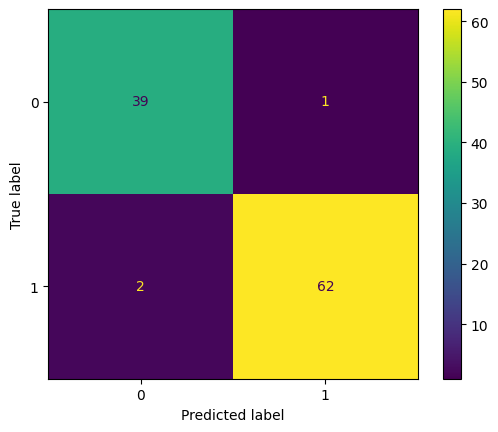

Log Loss: 0.06899900768078696


In [14]:
# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

evaluation(model, X_test, y_test)

Log loss report seems most promising for random forest classifier so will perform hyperparameter tuning and further evaluation with random forest algorithm

In [15]:
# source https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# mplement a grid search using GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid=param_grid, cv=10)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Estimator: RandomForestClassifier(class_weight='balanced', max_depth=10)


Update the parameters of the model by those which are obtained by using GridSearchCV

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        41
           1       0.97      0.98      0.98        63

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104

Accuracy Score: 0.9711538461538461


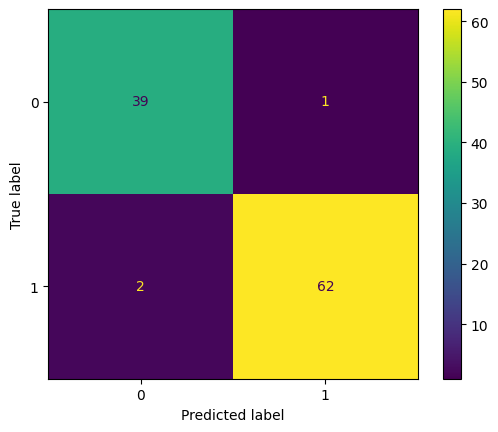

Log Loss: 0.07486415477748488


In [16]:
model_grid = RandomForestClassifier(max_depth=grid_search.best_params_['max_depth'],
                                    n_estimators=grid_search.best_params_['n_estimators'],
                                    bootstrap = grid_search.best_params_['bootstrap'],
                                    class_weight='balanced')
model_grid.fit(X_train, y_train)

evaluation(model_grid, X_test, y_test)
# testing
y_pred_grid = model_grid.predict(X_test)


Plotting results

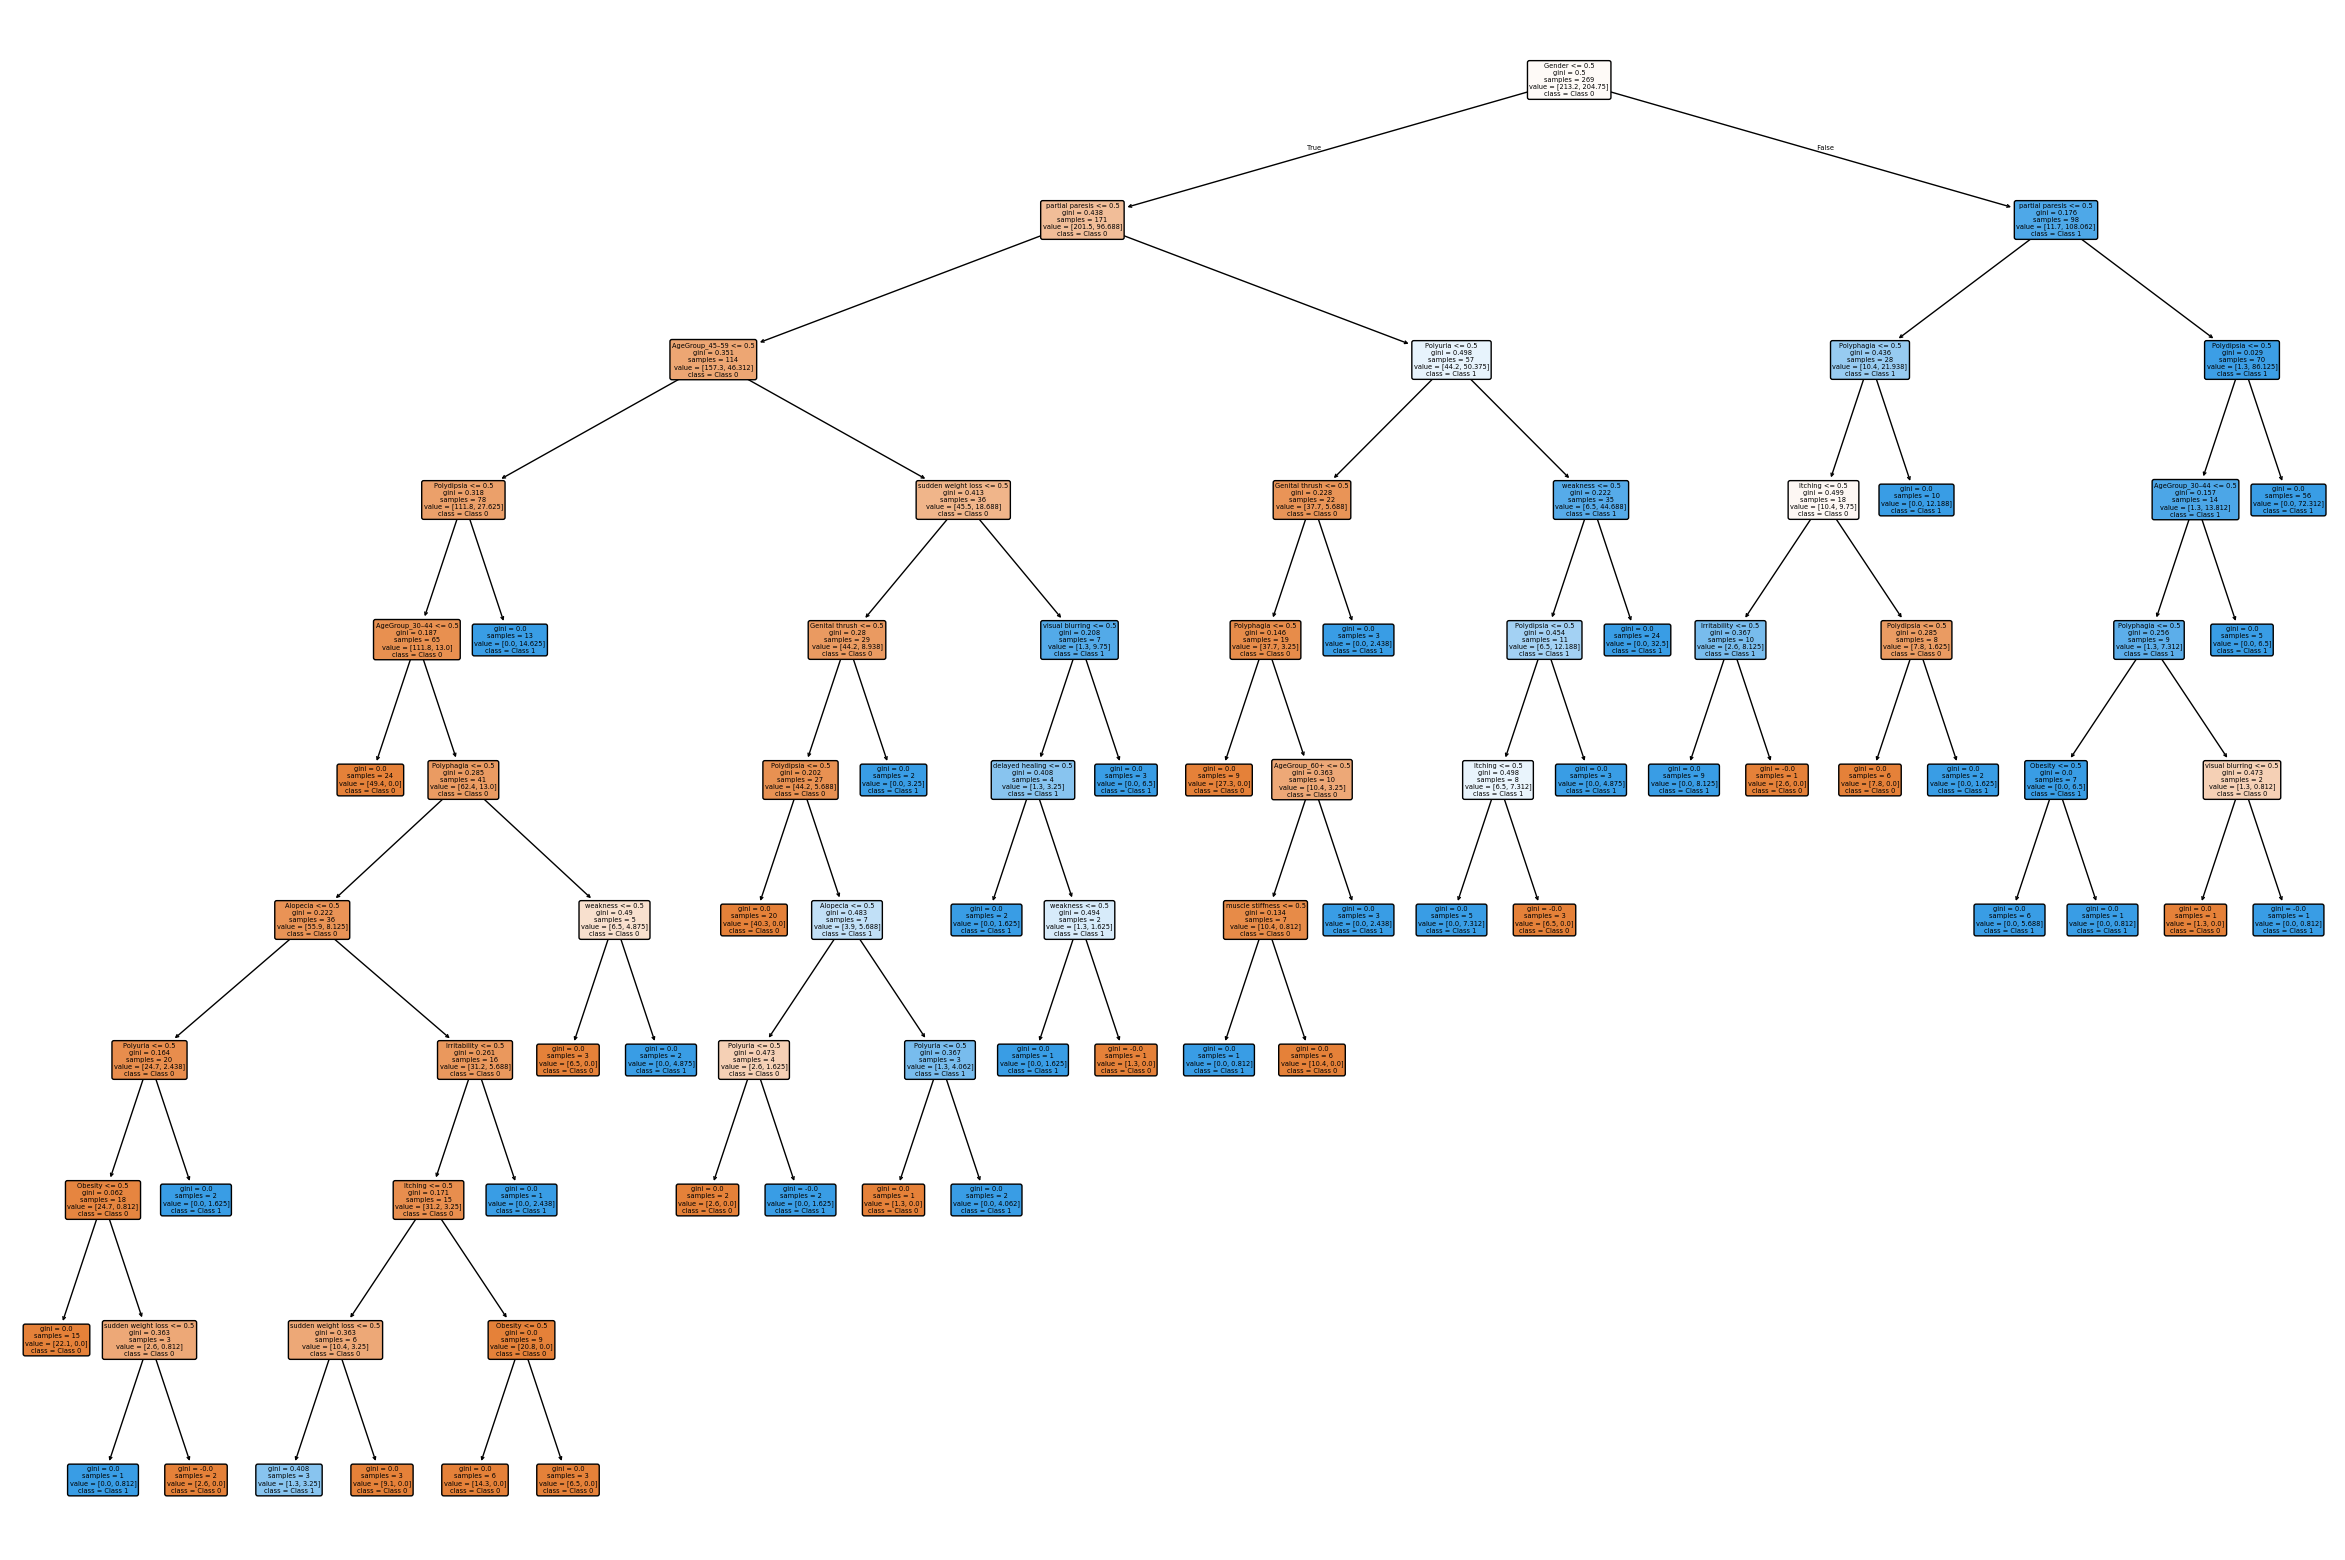

In [17]:
# Access the first tree (index 0) from your random forest 'rf'
# Could have more trees
plt.figure(figsize=(30,20))
plot_tree(model_grid.estimators_[0], 
          feature_names=X.columns, 
          class_names=['Class 0', 'Class 1'], 
          filled=True, 
          rounded=True)
plt.show()

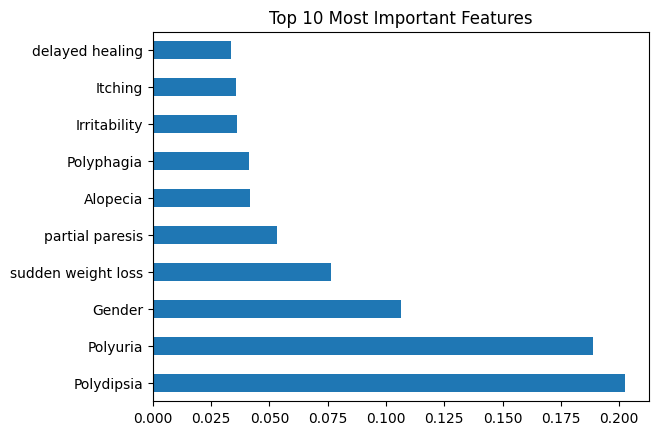

In [18]:
# Create a Series with feature importances
importances = pd.Series(model_grid.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh') # top 10
plt.title("Top 10 Most Important Features")
plt.show()

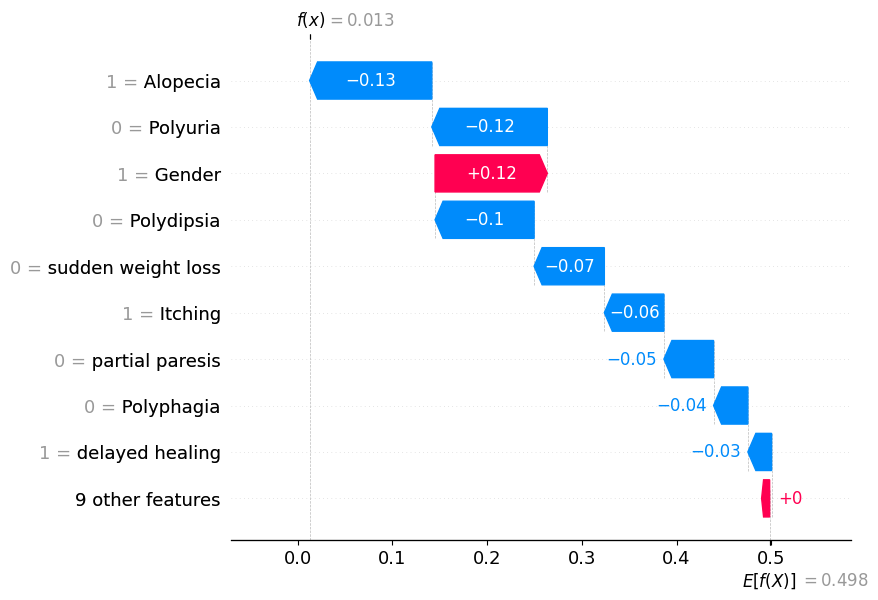

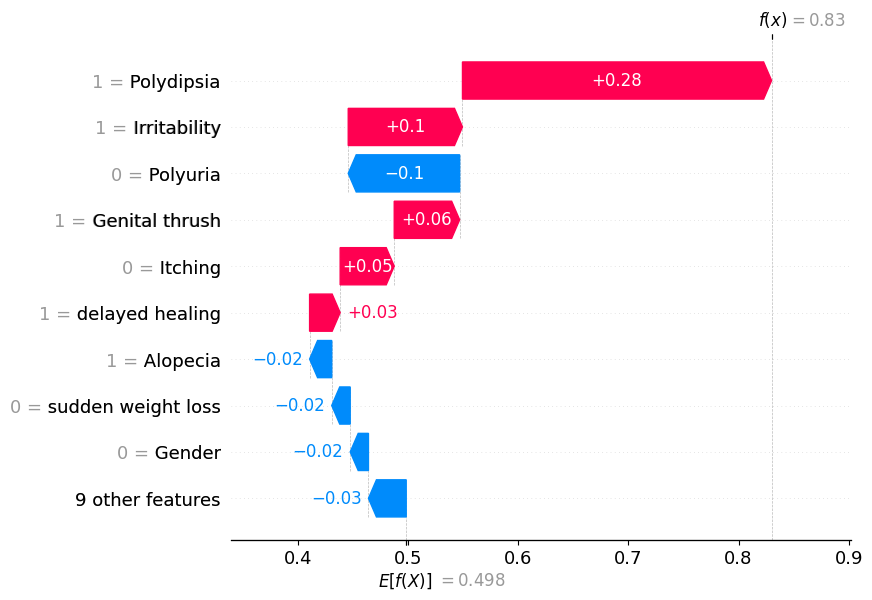

In [19]:
# SHAP
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(model_grid)
shap_values = explainer(X_test) # Calculate SHAP values for the test set

# Local Explanation: Waterfall Plot
# Shows why the model made a specific prediction (e.g., for the first test row)
# Note: For classification, we specify index [:, :, 1] for the 'Positive' class
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

C:\Users\shafe\AppData\Local\Temp\ipykernel_2388\2344957999.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


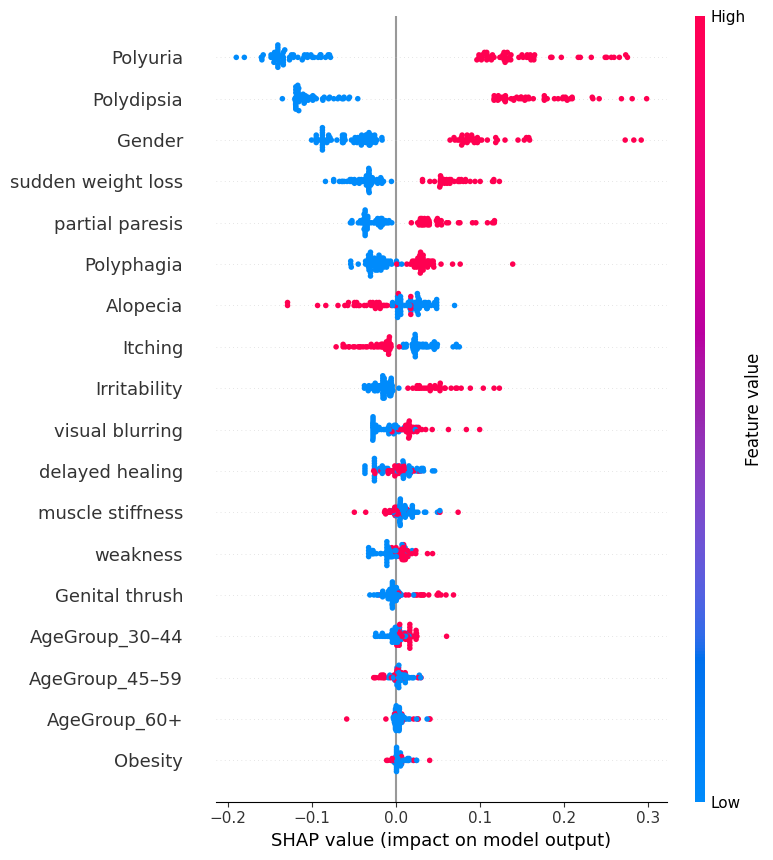

In [20]:
shap.summary_plot(shap_values[:, :, 1], X_test)

Experimenting with XGBoost

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.95      0.98      0.97        62

    accuracy                           0.96       104
   macro avg       0.96      0.96      0.96       104
weighted avg       0.96      0.96      0.96       104

Accuracy Score: 0.9615384615384616


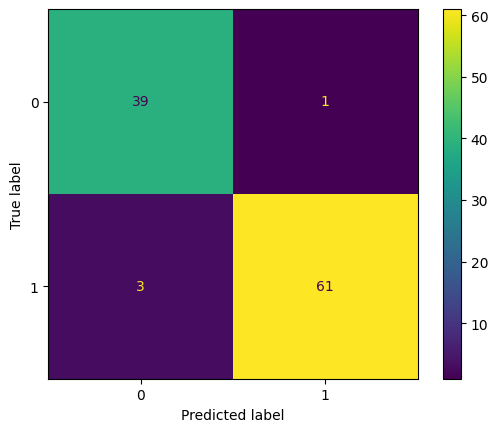

Log Loss: 0.05976042126110299


In [21]:
# Train a model
model_xgb = xgboost.XGBClassifier()
model_xgb.fit(X_train, y_train)
evaluation(model_xgb, X_test, y_test)

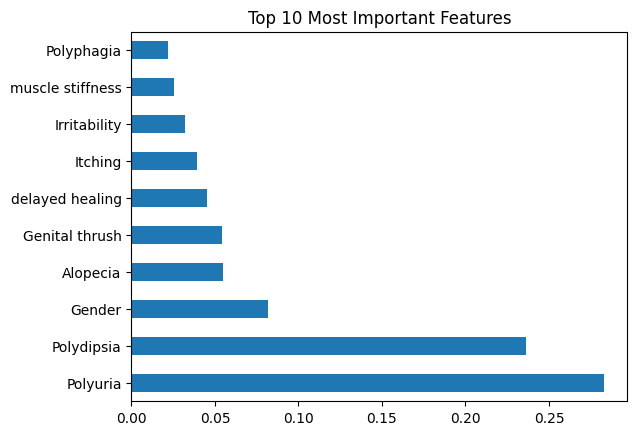

In [22]:
# Create a Series with feature importances
importances = pd.Series(model_xgb.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh') # top 10
plt.title("Top 10 Most Important Features")
plt.show()

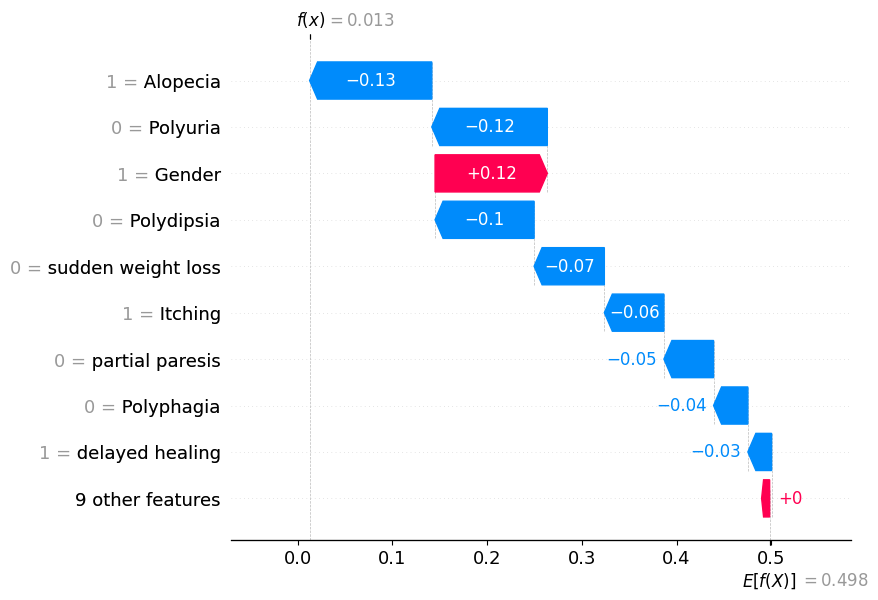

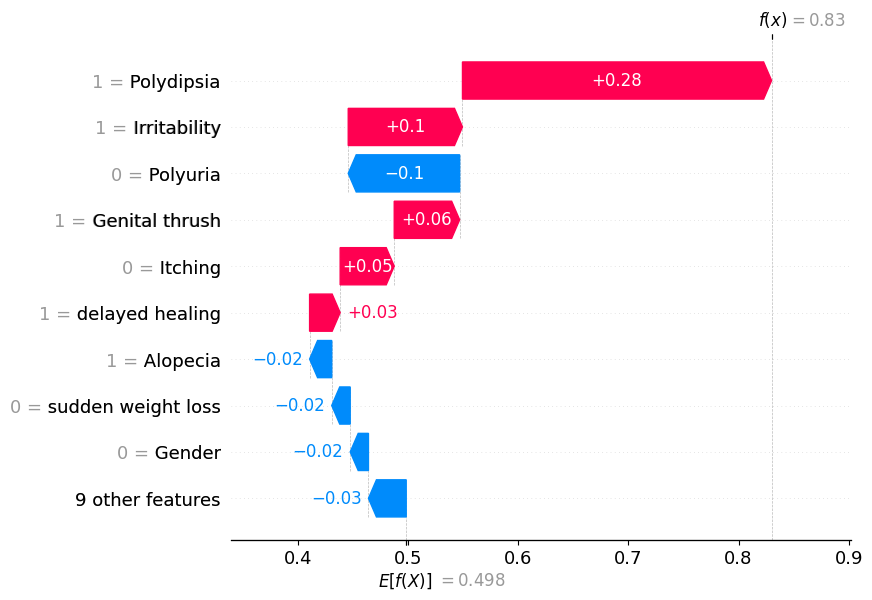

In [23]:
# SHAP
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(model_grid)
shap_values = explainer(X_test) # Calculate SHAP values for the test set

# Local Explanation: Waterfall Plot
# Shows why the model made a specific prediction (e.g., for the first test row)
# Note: For classification, we specify index [:, :, 1] for the 'Positive' class
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

C:\Users\shafe\AppData\Local\Temp\ipykernel_2388\2344957999.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


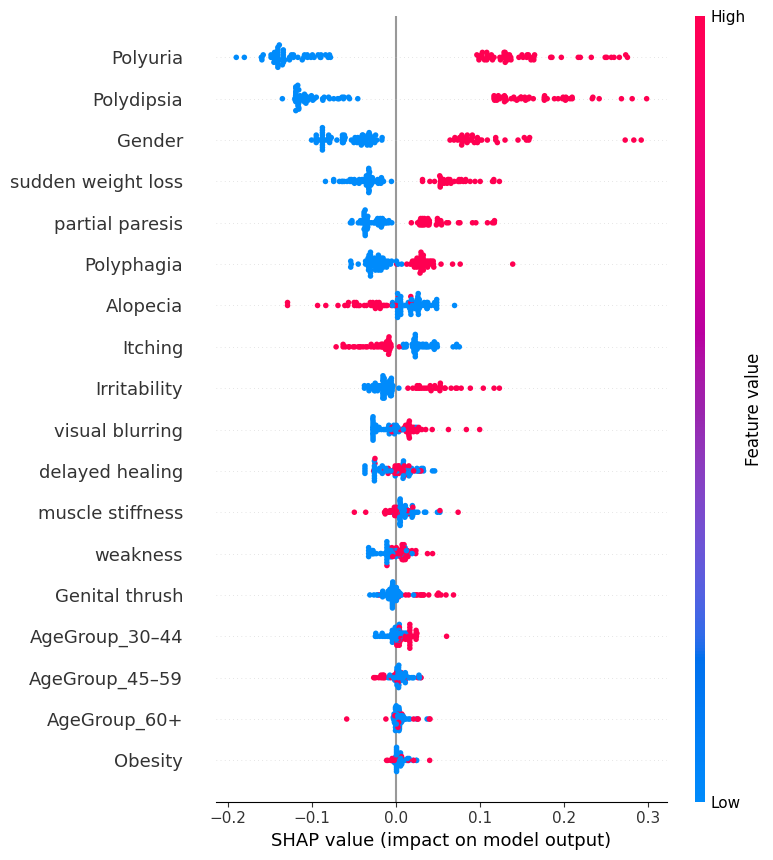

In [24]:
shap.summary_plot(shap_values[:, :, 1], X_test)